# **El salario sube, pero… ¿alcanza para más?**
Un análisis del ingreso laboral frente a la inflación.


¿Que los ingresos aumenten significa necesariamente que las personas pueden comprar más? Este análisis parte precisamente de esa pregunta. Utilizando datos de la GEIH para diciembre de 2024 y 2025, se estudia la evolución de los ingresos laborales considerando el efecto de la inflación.

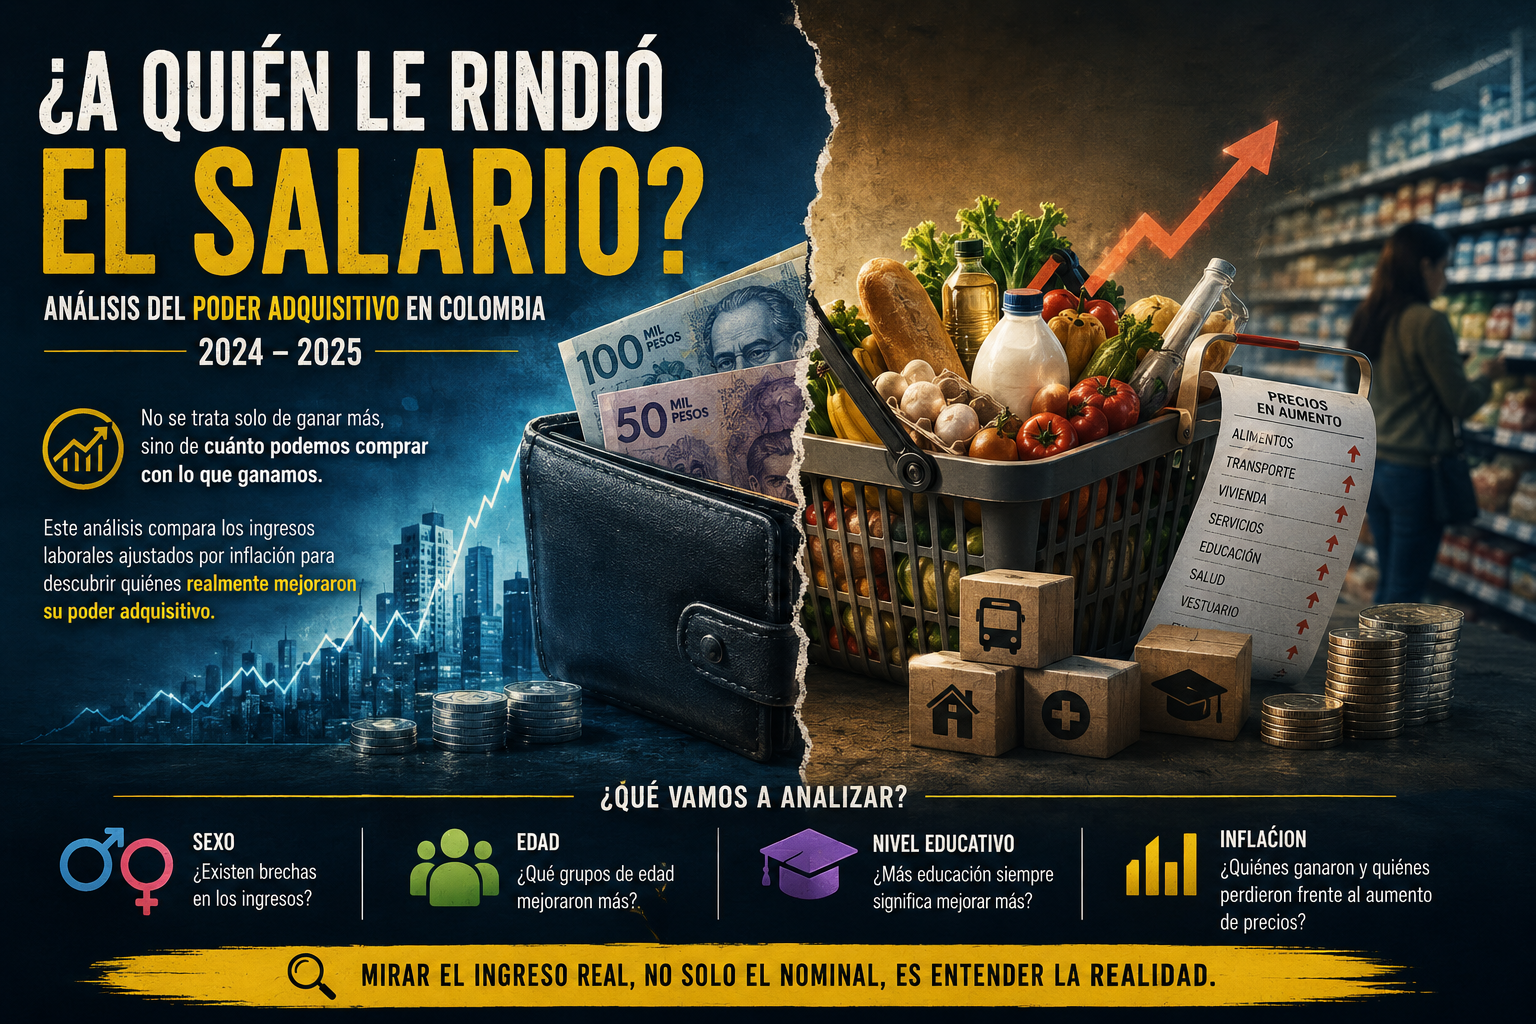

# Importación de librerías y carga de datos

**Nota sobre el prealistamiento de los datos**: Debido al tamaño de las bases de datos originales (+60.000 registros), se realizó un prealistamiento con apoyo de IA, seleccionando una cantidad de registros que permitiera trabajar con una base manejable para el ejercicio mediante muestreo aleatorio estratificado proporcional. La selección buscó conservar características y comportamientos coherentes con los datos originales, sin modificar los valores de los registros. Este procedimiento se realizó con fines prácticos y académicos, con el fin de contar con las condiciones necesarias para resolver la pregunta problema y desarrollar el ejercicio computacional.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

url_2024 = "https://raw.githubusercontent.com/Maria-Alejandra-Soto-Escobar/UC_PAD_cuadernos_jupyter_MA/refs/heads/main/2024.csv"
url_2025 = "https://raw.githubusercontent.com/Maria-Alejandra-Soto-Escobar/UC_PAD_cuadernos_jupyter_MA/refs/heads/main/2025.csv"

B2024 = pd.read_csv(url_2024, sep=",")
B2025 = pd.read_csv(url_2025, sep=",")

print("Dimensiones base 2024:", B2024.shape)
print("Dimensiones base 2025:", B2025.shape)

Dimensiones base 2024: (20000, 11)
Dimensiones base 2025: (20000, 11)


# Visualización de la estructura

In [11]:
print("Columnas base 2024:")
print(B2024.columns.tolist())

print("\nColumnas base 2025:")
print(B2025.columns.tolist())

Columnas base 2024:
['directorio', 'secuencia_p', 'orden', 'hogar', 'regis', 'per', 'p3271', 'p6040', 'p3042', 'inglabo', 'id_registro_original']

Columnas base 2025:
['directorio', 'secuencia_p', 'orden', 'hogar', 'regis', 'per', 'p3271', 'p6040', 'p3042', 'inglabo', 'id_registro_original']


In [12]:
print("Tipos de datos 2024:")
print(B2024.dtypes)

print("\nTipos de datos 2025:")
print(B2025.dtypes)

Tipos de datos 2024:
directorio                int64
secuencia_p               int64
orden                     int64
hogar                     int64
regis                     int64
per                       int64
p3271                     int64
p6040                     int64
p3042                   float64
inglabo                 float64
id_registro_original      int64
dtype: object

Tipos de datos 2025:
directorio                int64
secuencia_p               int64
orden                     int64
hogar                     int64
regis                     int64
per                       int64
p3271                     int64
p6040                     int64
p3042                   float64
inglabo                 float64
id_registro_original      int64
dtype: object


# Normalización de columnas

In [13]:
nombres_columnas = {
    "p3271": "sexo",
    "p6040": "edad",
    "p3042": "educación",
    "inglabo": "ingresos_laborales"
}

B2024 = B2024.rename(columns=nombres_columnas)
B2025 = B2025.rename(columns=nombres_columnas)

## Normalización de valores en las columnas

In [14]:
#El sexo viene escrito en formato númerico. Se traduce a texto con un diccionario
sexo = {
    1: "Hombre",
    2: "Mujer"
}

B2024["sexo"] = B2024["sexo"].map(sexo)
B2025["sexo"] = B2025["sexo"].map(sexo)

print("Sexos en 2024:")
print(B2024["sexo"].value_counts())

print("\nSexos en 2025:")
print(B2025["sexo"].value_counts())

Sexos en 2024:
sexo
Mujer     10645
Hombre     9355
Name: count, dtype: int64

Sexos en 2025:
sexo
Mujer     10614
Hombre     9386
Name: count, dtype: int64


In [15]:
#El nivel educativo viene escrito de formato númerico. Se traduce a texto con un diccionario:
nivel_educativo = {
    1: "Ninguno",
    2: "Preescolar",
    3: "Primaria",
    4: "Secundaria",
    5: "Bachillerato_clásico",
    6: "Bachillerato_técnico",
    7: "Normalista",
    8: "Técnica_profesional",
    9: "Tecnológica",
    10: "Universitaria",
    11: "Especialización",
    12: "Maestría",
    13: "Doctorado",
    99: "No_sabe,_no_informa"
}

B2024["educación"] = B2024["educación"].map(nivel_educativo)
B2025["educación"] = B2025["educación"].map(nivel_educativo)

print("Niveles educativos en 2024:")
print(B2024["educación"].value_counts())

print("\nNiveles educativos en 2025:")
print(B2025["educación"].value_counts())

Niveles educativos en 2024:
educación
Bachillerato_clásico    6263
Primaria                3452
Universitaria           3216
Secundaria              2034
Técnica_profesional     1851
Tecnológica              954
Especialización          778
Bachillerato_técnico     517
Ninguno                  484
Maestría                 355
Doctorado                 46
Normalista                43
Preescolar                 2
Name: count, dtype: int64

Niveles educativos en 2025:
educación
Bachillerato_clásico    6467
Universitaria           3311
Primaria                3191
Secundaria              2023
Técnica_profesional     1932
Tecnológica              908
Especialización          715
Bachillerato_técnico     539
Ninguno                  467
Maestría                 345
Doctorado                 58
Normalista                38
Preescolar                 3
Name: count, dtype: int64


# Creación de nuevas tablas con columnas de interés

In [16]:
columnas = [
    "sexo",
    "edad",
    "educación",
    "ingresos_laborales"
]

Tabla_2024 = B2024[columnas].copy()
Tabla_2025 = B2025[columnas].copy()

print("Primeros registros de 2024:")
display(Tabla_2024.head())

print("Primeros registros de 2025:")
display(Tabla_2025.head())


Primeros registros de 2024:


,sexo,edad,educación,ingresos_laborales
0,Mujer,41,Bachillerato_técnico,1100000.0
1,Hombre,23,Primaria,1300000.0
2,Mujer,20,Bachillerato_clásico,430000.0
3,Mujer,60,Universitaria,1600000.0
4,Hombre,30,Bachillerato_clásico,2000000.0


Primeros registros de 2025:


,sexo,edad,educación,ingresos_laborales
0,Mujer,41,Maestría,13000000.0
1,Mujer,41,Secundaria,1620000.0
2,Hombre,42,Secundaria,780000.0
3,Mujer,25,Bachillerato_clásico,1800000.0
4,Mujer,20,Bachillerato_clásico,800000.0


# Limpieza de los  datos

######Los registros que tengan valores faltantes en cada una de las variables de interes de las tablas, no se toman en cuenta para el análisis, porque impiden realizar correctamente las comparaciones y cálculos requeridos.

In [17]:
#Cuantos datos faltantes tiene cada columna
print("Valores faltantes en 2024:")
print(Tabla_2024.isnull().sum())

print("\nValores faltantes en 2025:")
print(Tabla_2025.isnull().sum())

Valores faltantes en 2024:
sexo                   0
edad                   0
educación              5
ingresos_laborales    23
dtype: int64

Valores faltantes en 2025:
sexo                   0
edad                   0
educación              3
ingresos_laborales    15
dtype: int64


In [18]:
#Eliminamos los faltantes
Tabla_2024 = Tabla_2024.dropna().copy()
Tabla_2025 = Tabla_2025.dropna().copy()

print("Registros después de eliminar valores faltantes:")
print("2024:", len(Tabla_2024))
print("2025:", len(Tabla_2025))

Registros después de eliminar valores faltantes:
2024: 19977
2025: 19985


In [19]:
#Comprobamos
print("Valores faltantes en 2024:")
print(Tabla_2024.isnull().sum())

print("\nValores faltantes en 2025:")
print(Tabla_2025.isnull().sum())

Valores faltantes en 2024:
sexo                  0
edad                  0
educación             0
ingresos_laborales    0
dtype: int64

Valores faltantes en 2025:
sexo                  0
edad                  0
educación             0
ingresos_laborales    0
dtype: int64


#Reglas de negocio

**Primera regla:** Los registros con ingresos laborales iguales o menores a 0 se excluyen del análisis, debido a que el estudio busca evaluar la evolución de ingresos laborales positivos entre 2024 y 2025. Los valores iguales a 0 no representan un ingreso laboral efectivo para realizar una comparación porcentual, mientras que los valores negativos no son coherentes con el concepto de ingreso laboral recibido. Por esta razón, se consideran datos no pertinentes para el cálculo del crecimiento nominal y real.

In [20]:
#Revisamos ingresos
print("Ingresos iguales a cero:")
print("2024:", (Tabla_2024["ingresos_laborales"] == 0).sum())
print("2025:", (Tabla_2025["ingresos_laborales"] == 0).sum())

print("\nIngresos negativos:")
print("2024:", (Tabla_2024["ingresos_laborales"] < 0).sum())
print("2025:", (Tabla_2025["ingresos_laborales"] < 0).sum())

Ingresos iguales a cero:
2024: 153
2025: 123

Ingresos negativos:
2024: 0
2025: 0


In [21]:
# Excluimos los registros con ingresos laborales iguales o menores a 0
Tabla_2024 = Tabla_2024[Tabla_2024["ingresos_laborales"] > 0].copy()
Tabla_2025 = Tabla_2025[Tabla_2025["ingresos_laborales"] > 0].copy()

print("Registros después de eliminar ingresos iguales o menores a cero:")
print("2024:", len(Tabla_2024))
print("2025:", len(Tabla_2025))

Registros después de eliminar ingresos iguales o menores a cero:
2024: 19824
2025: 19862


**Segunda regla:** Las personas menores de 18 años serán excluidas del análisis debido a que el estudio se enfoca en la evolución de los ingresos laborales de la población mayor de edad. Incluir registros correspondientes a menores de edad podría incorporar observaciones que no representan adecuadamente el comportamiento de los ingresos laborales del grupo de interés y afectar la comparabilidad de los resultados.

In [22]:
# Identificar los registros de personas menores de 18 años
menores_2024 = Tabla_2024[Tabla_2024["edad"] < 18].shape[0]
menores_2025 = Tabla_2025[Tabla_2025["edad"] < 18].shape[0]

print("Personas menores de 18 años en 2024:", menores_2024)
print("Personas menores de 18 años en 2025:", menores_2025)

Personas menores de 18 años en 2024: 119
Personas menores de 18 años en 2025: 111


In [23]:
# Excluir las personas menores de 18 años
Tabla_2024 = Tabla_2024[Tabla_2024["edad"] >= 18].copy()
Tabla_2025 = Tabla_2025[Tabla_2025["edad"] >= 18].copy()

print("Registros después de excluir menores de edad:")
print("2024:", len(Tabla_2024))
print("2025:", len(Tabla_2025))

Registros después de excluir menores de edad:
2024: 19705
2025: 19751


# Análisis descriptivo
Con el fin de determinar qué medida de tendencia central utilizar para realizar el análisis y dar respuesta a nuestra pregunta problema, se realizó un análisis descriptivo de los ingresos laborales de 2024 y 2025 para observar la distribución de los datos y la presencia de valores elevados.

In [24]:
#Calculamos las estadísticas descriptivas de los ingresos laborales en ambos años
estadisticas_2024 = Tabla_2024["ingresos_laborales"].describe()
estadisticas_2025 = Tabla_2025["ingresos_laborales"].describe()

resumen_ingresos = pd.DataFrame({
    "2024": estadisticas_2024,
    "2025": estadisticas_2025
})

resumen_ingresos.index = [
    "Cantidad de registros",
    "Media",
    "Desviación estándar",
    "Mínimo",
    "Primer cuartil (25%)",
    "Mediana (50%)",
    "Tercer cuartil (75%)",
    "Máximo"
]

resumen_ingresos.style.format("{:,.2f}")

,2024,2025
Cantidad de registros,"19,705.00","19,751.00"
Media,"1,719,221.56","1,875,402.44"
Desviación estándar,"2,408,610.52","2,542,869.90"
Mínimo,"100,000.00","100,000.00"
Primer cuartil (25%),"800,000.00","880,000.00"
Mediana (50%),"1,300,000.00","1,423,500.00"
Tercer cuartil (75%),"1,800,000.00","2,000,000.00"
Máximo,"100,000,000.00","92,000,000.00"


In [25]:
#Comparación entre media y mediana
print("Comparación entre media y mediana:")

print("\n2024")
print("Media:", f"${Tabla_2024['ingresos_laborales'].mean():,.0f}")
print("Mediana:", f"${Tabla_2024['ingresos_laborales'].median():,.0f}")

print("\n2025")
print("Media:", f"${Tabla_2025['ingresos_laborales'].mean():,.0f}")
print("Mediana:", f"${Tabla_2025['ingresos_laborales'].median():,.0f}")

Comparación entre media y mediana:

2024
Media: $1,719,222
Mediana: $1,300,000

2025
Media: $1,875,402
Mediana: $1,423,500


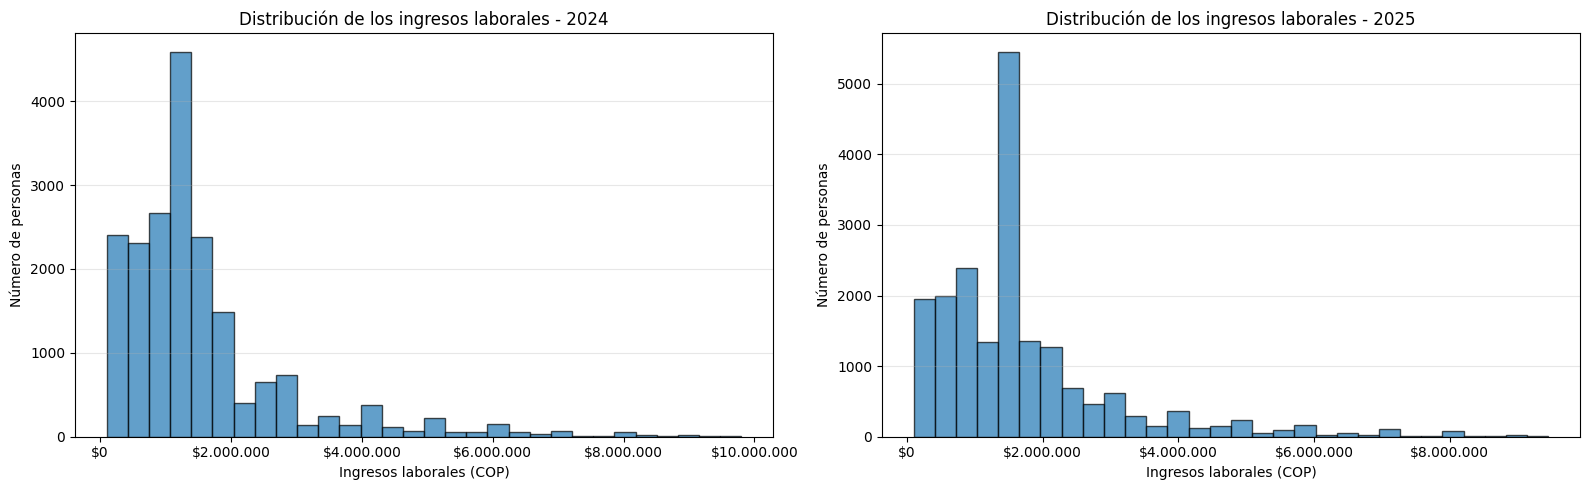

In [26]:
# Histogramas de ingresos laborales 2024 y 2025
ingresos_2024 = Tabla_2024["ingresos_laborales"]
ingresos_2025 = Tabla_2025["ingresos_laborales"]

#Percentil 99 para mejorar únicamente la visualización
limite_2024 = ingresos_2024.quantile(0.99)
limite_2025 = ingresos_2025.quantile(0.99)

datos_2024 = ingresos_2024[ingresos_2024 <= limite_2024]
datos_2025 = ingresos_2025[ingresos_2025 <= limite_2025]

# Creamos los dos gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma 2024
axes[0].hist(
    datos_2024,
    bins=30,
    edgecolor="black",
    alpha=0.7
)

axes[0].set_title("Distribución de los ingresos laborales - 2024")
axes[0].set_xlabel("Ingresos laborales (COP)")
axes[0].set_ylabel("Número de personas")

# Histograma 2025
axes[1].hist(
    datos_2025,
    bins=30,
    edgecolor="black",
    alpha=0.7
)

axes[1].set_title("Distribución de los ingresos laborales - 2025")
axes[1].set_xlabel("Ingresos laborales (COP)")
axes[1].set_ylabel("Número de personas")

# Formato de pesos colombianos
formato_eje = ticker.FuncFormatter(
    lambda x, pos: "$" + f"{x:,.0f}".replace(",", ".")
)

axes[0].xaxis.set_major_formatter(formato_eje)
axes[1].xaxis.set_major_formatter(formato_eje)

# Cuadrícula
axes[0].grid(axis="y", alpha=0.3)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

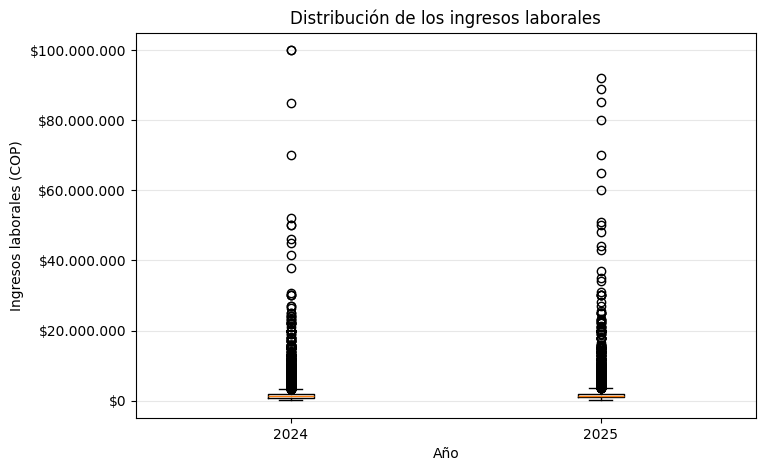

In [27]:
#Gráfico
plt.figure(figsize=(8, 5))

plt.boxplot([
    Tabla_2024["ingresos_laborales"],
    Tabla_2025["ingresos_laborales"]
])

plt.xticks([1, 2], ["2024", "2025"])

plt.title("Distribución de los ingresos laborales")
plt.xlabel("Año")
plt.ylabel("Ingresos laborales (COP)")

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: "$" + f"{x:,.0f}".replace(",", "."))
)

plt.grid(axis="y", alpha=0.3)

plt.show()

######Los resultados muestran que, aunque la mayor concentración de los ingresos se encuentra en valores inferiores, también se presentan ingresos considerablemente elevados. Estos valores no se consideran necesariamente incorrectos, ya que pueden corresponder a situaciones reales; sin embargo, pueden tener una influencia importante sobre el promedio.

#####Por lo anterior, se decidió utilizar la mediana como medida de tendencia central para el análisis, debido a que es menos sensible a la influencia de valores extremos y permite representar de manera más adecuada el comportamiento central de los ingresos laborales.

#Cálculos del análisis general

**Dos anotaciones**

**Primera:** La mediana de 2024 representa el valor de referencia inicial o punto de partida del ingreso del segmento, mientras que la mediana de 2025 representa el valor de referencia final del año actual. La comparación entre ambas permite calcular la variación nominal del ingreso del segmento entre los dos años.

**Segunda:** La inflación utilizada para ajustar el crecimiento nominal de los ingresos entre diciembre de 2024 y diciembre de 2025 es la anual del Índice de Precios al Consumidor (IPC) reportada por el DANE para diciembre de 2025, correspondiente al 5,10 %. Este indicador representa la variación de precios entre diciembre de 2024 y diciembre de 2025.

In [28]:
#Inflación del periodo
inflacion = (5.10)

# Crecimiento nominal
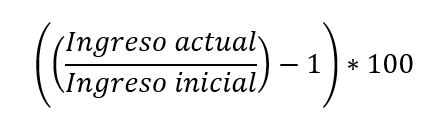

In [29]:
#Calculamos crecimiento nominal
def calcular_crecimiento_nominal(valor_2024, valor_2025):
    crecimiento = ((valor_2025 / valor_2024) - 1) * 100
    return crecimiento

crecimiento_nominal = calcular_crecimiento_nominal(
    Tabla_2024["ingresos_laborales"].median(),
    Tabla_2025["ingresos_laborales"].median()
)

print("Crecimiento nominal:", round(crecimiento_nominal, 2), "%")

Crecimiento nominal: 9.5 %


# Crecimiento real
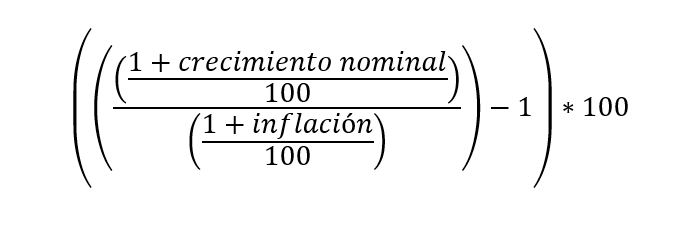

In [30]:
#Calculamos crecimiento real
def calcular_crecimiento_real(crecimiento_nominal, inflacion):
    crecimiento_real = (
        (1 + crecimiento_nominal / 100) /
        (1 + inflacion / 100)
        - 1
    ) * 100

    return crecimiento_real

crecimiento_real = calcular_crecimiento_real(
    crecimiento_nominal,
    inflacion
)

print("Crecimiento real:", round(crecimiento_real, 2), "%")


Crecimiento real: 4.19 %


# Clasificación general del crecimiento real

In [31]:
def clasificar_resultado(crecimiento_real):

    if pd.isna(crecimiento_real):
        return "No comparable"
    elif crecimiento_real >= 1:
        return "Mejora real"
    elif crecimiento_real >= -1:
        return "Conservación aproximada"
    elif crecimiento_real > -5:
        return "Pérdida moderada"
    else:
        return "Pérdida crítica"

clasificacion = clasificar_resultado(crecimiento_real)

print("Clasificación:", clasificacion)

Clasificación: Mejora real


# Resultado general

In [32]:
def calcular_resultado_general(Tabla_2024, Tabla_2025):

    mediana_2024 = Tabla_2024["ingresos_laborales"].median()
    mediana_2025 = Tabla_2025["ingresos_laborales"].median()

    crecimiento_nominal = calcular_crecimiento_nominal(
        mediana_2024,
        mediana_2025
    )

    crecimiento_real = calcular_crecimiento_real(
        crecimiento_nominal,
        inflacion
    )

    clasificacion = clasificar_resultado(crecimiento_real)

    resultado = {
        "Mediana 2024": mediana_2024,
        "Mediana 2025": mediana_2025,
        "Crecimiento nominal (%)": crecimiento_nominal,
        "Crecimiento real (%)": crecimiento_real,
        "Clasificación": clasificacion
    }

    return resultado


resultado_general = calcular_resultado_general(
    Tabla_2024,
    Tabla_2025
)

resultado_general_df = pd.DataFrame(
    [resultado_general],
    index=["Total población"]
)

resultado_general_df.style.format({
    "Mediana 2024": "${:,.0f}",
    "Mediana 2025": "${:,.0f}",
    "Crecimiento nominal (%)": "{:.2f}%",
    "Crecimiento real (%)": "{:.2f}%"
})

,Mediana 2024,Mediana 2025,Crecimiento nominal (%),Crecimiento real (%),Clasificación
Total población,"$1,300,000","$1,423,500",9.50%,4.19%,Mejora real


# Análisis por grupos (sexo, edad, educación)

In [33]:
#Construimos rangos de edad para que la comparación final sea más interpretable que trabajar edad por edad
def rango_edad(edad):

    if 18 <= edad <= 24:
        return "18-24"
    elif edad <= 34:
        return "25-34"
    elif edad <= 44:
        return "35-44"
    elif edad <= 54:
        return "45-54"
    elif edad <= 64:
        return "55-64"
    else:
        return "65 o más"

Tabla_2024["rango_edad"] = Tabla_2024["edad"].apply(rango_edad)
Tabla_2025["rango_edad"] = Tabla_2025["edad"].apply(rango_edad)

print("Rangos de edad en 2024:")
print(Tabla_2024["rango_edad"].value_counts().sort_index())

print("\nRangos de edad en 2025:")
print(Tabla_2025["rango_edad"].value_counts().sort_index())


Rangos de edad en 2024:
rango_edad
18-24       2038
25-34       4755
35-44       4824
45-54       3904
55-64       2955
65 o más    1229
Name: count, dtype: int64

Rangos de edad en 2025:
rango_edad
18-24       2094
25-34       5016
35-44       4813
45-54       3813
55-64       2766
65 o más    1249
Name: count, dtype: int64


In [34]:
#Definimos una función
def analizar_por_grupo(Tabla_2024, Tabla_2025, variable):

    promedio_2024 = Tabla_2024.groupby(variable)["ingresos_laborales"].mean()
    promedio_2025 = Tabla_2025.groupby(variable)["ingresos_laborales"].mean()
    mediana_2024 = Tabla_2024.groupby(variable)["ingresos_laborales"].median()
    mediana_2025 = Tabla_2025.groupby(variable)["ingresos_laborales"].median()


    resultados = pd.DataFrame({

        "Promedio 2024": promedio_2024,
        "Promedio 2025": promedio_2025,
        "Mediana 2024": mediana_2024,
        "Mediana 2025": mediana_2025
    })

    resultados["Crecimiento nominal (%)"] = resultados.apply(
        lambda fila: calcular_crecimiento_nominal(
            fila["Mediana 2024"],
            fila["Mediana 2025"]
        ),
        axis=1
    )

    resultados["Crecimiento real (%)"] = resultados[
        "Crecimiento nominal (%)"
    ].apply(
        lambda crecimiento: calcular_crecimiento_real(
            crecimiento,
            inflacion
        )
    )

    resultados["Clasificación"] = resultados[
        "Crecimiento real (%)"
    ].apply(clasificar_resultado)

    return resultados

In [35]:
# Elegimos qué grupo analizar
opcion = int(input("""
Seleccione el grupo que desea analizar:

1. Sexo
2. Nivel educativo
3. Rango de edad

Digite una opción: """))

if opcion == 1:
    grupo = "sexo"
    titulo = "Resultados por sexo"

elif opcion == 2:
    grupo = "educación"
    titulo = "Resultados por nivel educativo"

elif opcion == 3:
    grupo = "rango_edad"
    titulo = "Resultados por rango de edad"

else:
    grupo = None
    titulo = None
    print("Opción no válida")

if opcion in [1, 2, 3]:

    resultados = analizar_por_grupo(
        Tabla_2024,
        Tabla_2025,
        grupo
    )

    print(f"\n{titulo}")

    display(
        resultados.style.format({
    "Promedio 2024": "${:,.0f}",
    "Promedio 2025": "${:,.0f}",
    "Mediana 2024": "${:,.0f}",
    "Mediana 2025": "${:,.0f}",
    "Crecimiento nominal (%)": "{:.2f}%",
    "Crecimiento real (%)": "{:.2f}%"})
    )


Seleccione el grupo que desea analizar:

1. Sexo
2. Nivel educativo
3. Rango de edad

Digite una opción: 2

Resultados por nivel educativo


,Promedio 2024,Promedio 2025,Mediana 2024,Mediana 2025,Crecimiento nominal (%),Crecimiento real (%),Clasificación
educación,,,,,,,
Bachillerato_clásico,"$1,264,081","$1,375,061","$1,300,000","$1,423,500",9.50%,4.19%,Mejora real
Bachillerato_técnico,"$1,347,461","$1,552,106","$1,300,000","$1,423,500",9.50%,4.19%,Mejora real
Doctorado,"$7,161,585","$9,130,000","$6,100,000","$7,000,000",14.75%,9.19%,Mejora real
Especialización,"$5,021,618","$5,627,421","$4,000,000","$4,500,000",12.50%,7.04%,Mejora real
Maestría,"$5,924,051","$6,262,102","$5,000,000","$5,000,000",0.00%,-4.85%,Pérdida moderada
Ninguno,"$695,972","$836,252","$600,000","$720,000",20.00%,14.18%,Mejora real
Normalista,"$1,706,220","$1,953,039","$1,600,000","$1,725,000",7.81%,2.58%,Mejora real
Preescolar,"$940,000","$505,000","$940,000","$505,000",-46.28%,-48.88%,Pérdida crítica
Primaria,"$933,985","$1,066,260","$800,000","$960,000",20.00%,14.18%,Mejora real


# Principales resultados y conclusiones

De acuerdo con los datos analizados en este trabajo se puede inferir que:

1. **Existe un cesgo en la igualdad de la mediana de hombres y mujeres:** Ambos presentan exactamente la misma mediana en 2024 (1.300.000) y en 2025 (1.423.500); sin embargo, el promedio de los hombres es mayor, en 2024 fue aproximadamente 1.800.000 frente a $1.600.000 de las mujeres, y en 2025 más de 2.000.000 frente a 1.860.000. Es decir, el trabajador central luce similar por sexo, pero en la distribución completa los hombres alcanzan ingresos más altos.

2. **Los mayores de 65 años son quienes más mejoraron su poder adquisitivo:** A pesar de esto, continúan entre quienes menos ganan. Su mediana aumentó de 750.000 a 900.000, equivalente a una mejora real del 14,18 %, la más alta por edad. Sin embargo, esos $900.000 siguen siendo la mediana más baja de todos los rangos.

3. **El título universitario sigue asociado a mayores ingresos:** Pero los técnicos profesionales casi igualaron su crecimiento. Los universitarios alcanzaron una mediana de 2.300.000 en 2025 mientras Técnica profesional llegó a 1.500.000, pero creció 9,79 % real. En otras palabras, el técnico gana menos, pero durante este periodo su poder adquisitivo creció ligeramente más rápido que el del universitario.

4. **Le aumentó mas el ingreso laboral a alguien con solo primaria:** Una persona del grupo de Primaria sigue teniendo un ingreso mediano mucho menor que una universitaria (960.000 frente a 2.300.000 en 2025), pero su poder adquisitivo creció más rápido: 14,18 % frente a 9,42 %.

5. **Los posgrados muestran que un salario alto no protege automáticamente contra la inflación:** Doctorado presenta el promedio más alto de toda la tabla en 2025 (9.130.000) y una mejora real del 9,19 %; Especialización también mejora 7,04 %.   
Sin embargo, la Maestría, pese a tener un promedio superior a 6.200.000, pierde 4,85 % de poder adquisitivo según la mediana.



# **Conclusión:** Ganar más y mejorar más son conceptos diferentes.

Algunos de los grupos con menores ingresos fueron los que más aumentaron su poder adquisitivo, mientras algunos de los ingresos más altos apenas crecieron o incluso perdieron frente a la inflación